**ITNPBD6-Machine Learning Assignment Autumn 2026**

**Telecom Customer Targeting**

**1. Data cleaning & Preprocessing**

Import "pandas" Library and Load dataset

In [41]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

In [42]:
df = pd.read_csv("wallacecommunications.csv")

In [43]:
df.shape

(50662, 20)

Inspect Data and Check Missing Values

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50662 entries, 0 to 50661
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         50662 non-null  int64  
 1   town                                       50662 non-null  object 
 2   country                                    50662 non-null  object 
 3   age                                        50662 non-null  int64  
 4   job                                        50662 non-null  object 
 5   married                                    50662 non-null  object 
 6   education                                  50662 non-null  object 
 7   arrears                                    50662 non-null  object 
 8   current_balance                            50662 non-null  float64
 9   housing                                    50662 non-null  object 
 10  has_tv_package        

In [45]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,yes
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,yes
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,yes
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,no
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,yes


Check for Duplicate Rows

In [46]:
df.duplicated().sum()

np.int64(0)

Check for Unique Values

In [47]:
df.nunique()

,0
ID,50644
town,101
country,5
age,76
job,12
married,3
education,4
arrears,2
current_balance,6928
housing,2


Idendify Column Data Types

In [48]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("Categorical columns: ", cat_col)
print("Numerical columns: ", num_col)

Categorical columns:  ['town', 'country', 'job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign', 'new_contract_this_campaign']
Numerical columns:  ['ID', 'age', 'current_balance', 'conn_tr', 'last_contact_this_campaign_day', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign']


Convert Target to Numeric

In [49]:
df['new_contract_this_campaign'] = df['new_contract_this_campaign'].map({'yes': 1, 'no': 0})

In [50]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,1
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,1
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,1
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,0
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,1


Check Target Balance

In [51]:
df['new_contract_this_campaign'].value_counts(normalize=True)

,proportion
new_contract_this_campaign,
0,0.804607
1,0.195393


Visualize Target Variable Distribution

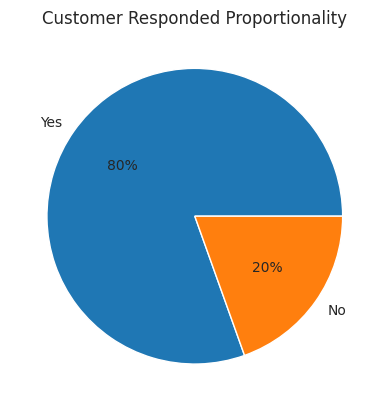

In [52]:
plt.pie(df['new_contract_this_campaign'].value_counts(), labels=['Yes', 'No'], autopct='%.f%%')
plt.title('Customer Responded Proportionality')
plt.show()

Statistical Summary & Visualize Outliers

In [53]:
df.drop(columns=['ID', 'new_contract_this_campaign']).describe().T

,count,mean,std,min,25%,50%,75%,max
age,50662.0,40.979373,10.919324,18.00,32.00,39.00,48.00,95.00
current_balance,50662.0,13.991210,30.899163,-80.19,0.82,4.72,14.95,984.17
conn_tr,50662.0,3.005093,1.409003,1.00,2.00,3.00,4.00,5.00
last_contact_this_campaign_day,50662.0,15.768525,8.347083,1.00,8.00,16.00,21.00,31.00
this_campaign,50662.0,2.713217,3.052227,1.00,1.00,2.00,3.00,63.00
days_since_last_contact_previous_campaign,50662.0,42.644408,102.238078,-1.00,-1.00,-1.00,-1.00,871.00
contacted_during_previous_campaign,50662.0,0.640283,2.358029,0.00,0.00,0.00,0.00,275.00


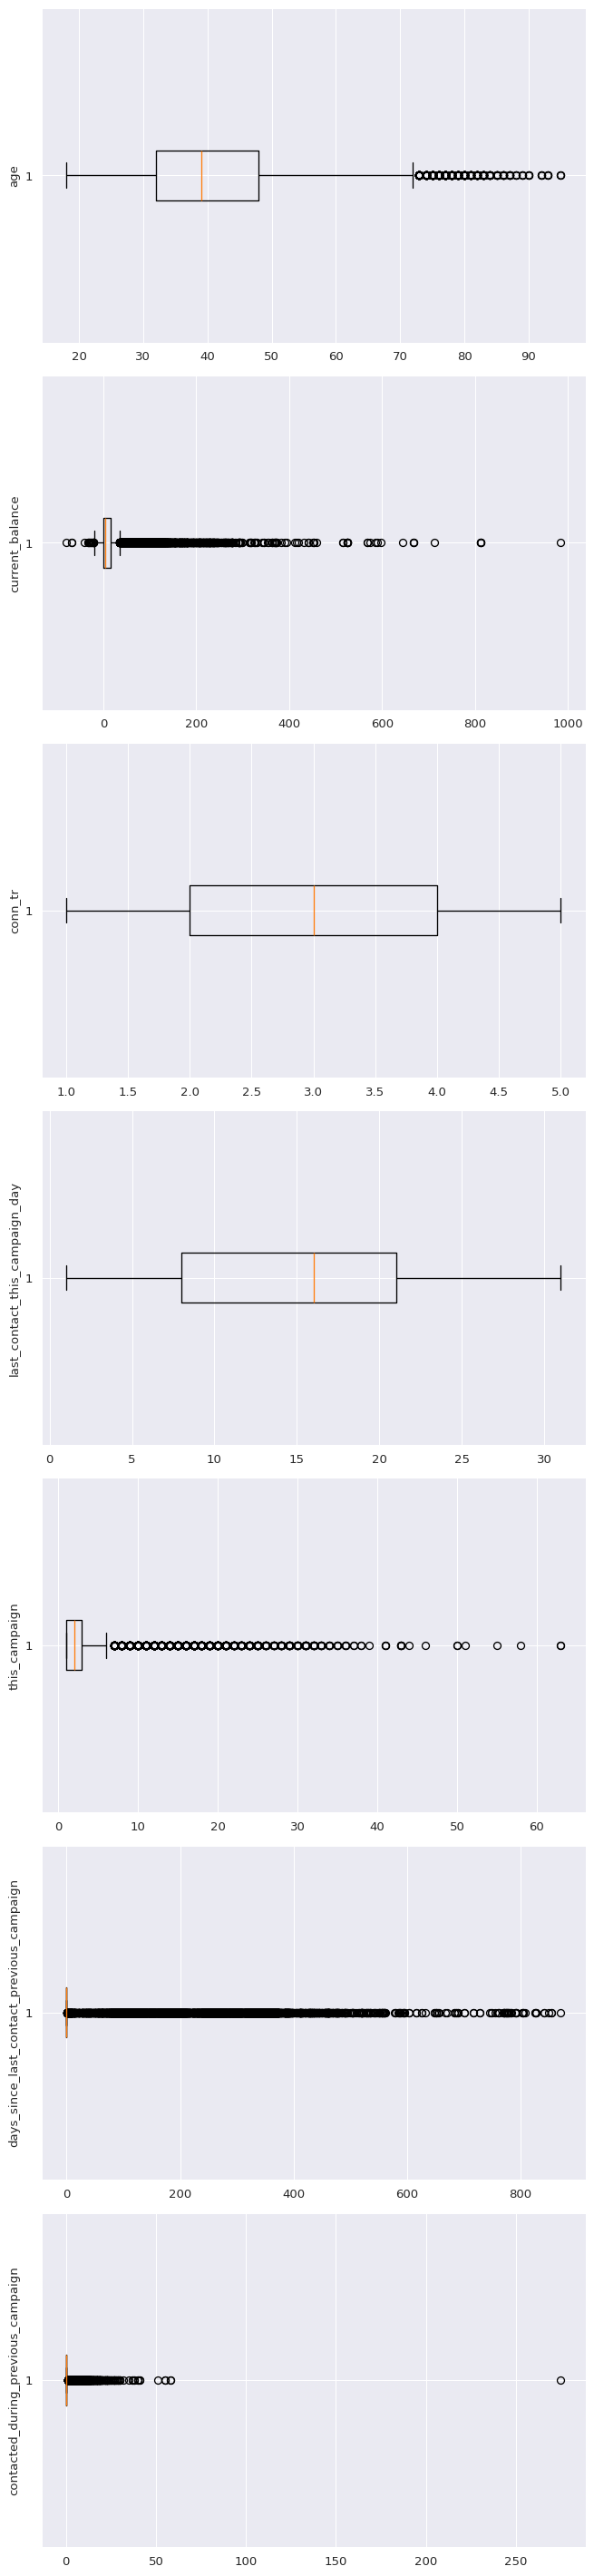

In [54]:
# Exclude ID
fix, axs = plt.subplots(len(num_col) - 1, 1, figsize=(7, 30), dpi=95)
for i, col in enumerate(num_col[1:]):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

Correlation Analysis

In [ ]:
pip install seaborn

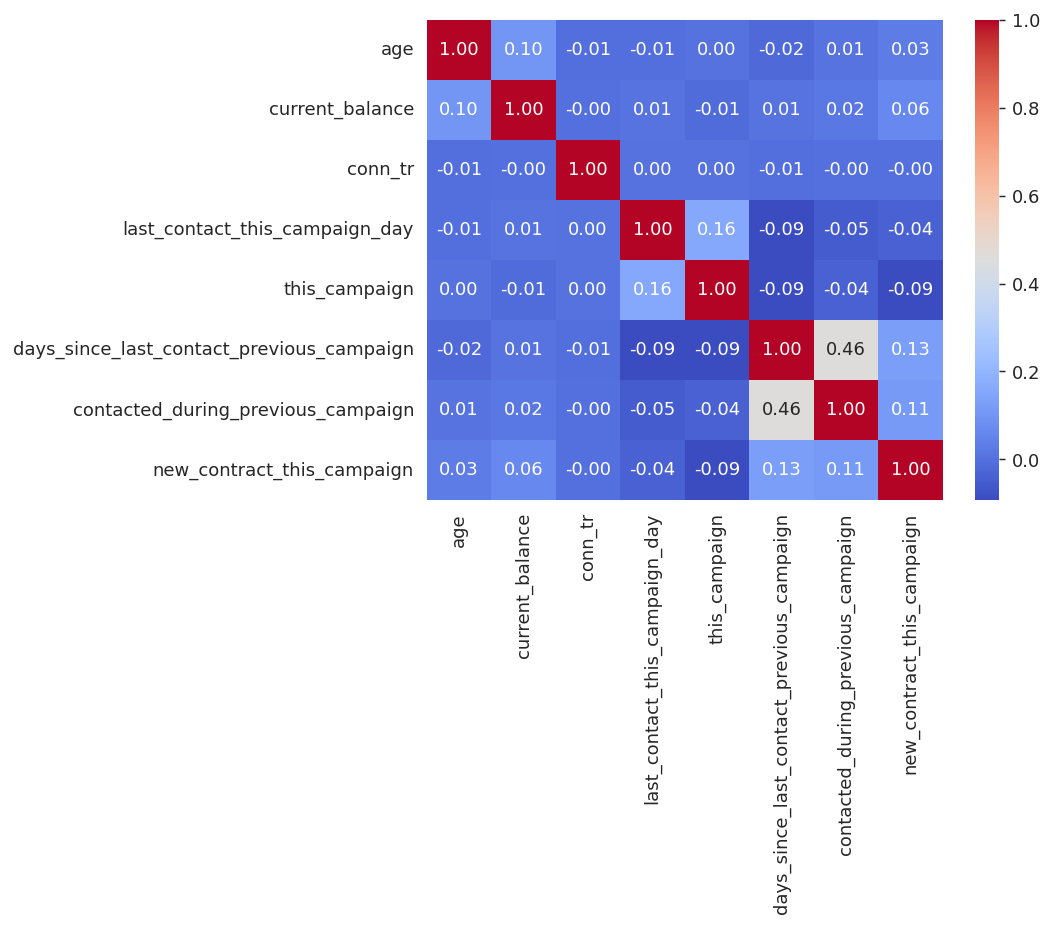

new_contract_this_campaign                   1.000000
days_since_last_contact_previous_campaign    0.126678
contacted_during_previous_campaign           0.112417
current_balance                              0.064008
age                                          0.030501
conn_tr                                     -0.002382
last_contact_this_campaign_day              -0.038615
this_campaign                               -0.091829
Name: new_contract_this_campaign, dtype: float64


In [55]:
df_corr = df.select_dtypes(include='number').drop(columns=['ID'])
corr = df_corr.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr["new_contract_this_campaign"].sort_values(ascending=False))

Overall, the correlation analysis shows that the non of the numerical columns have strong linear relationships with target variable. With weak correlation, removing outliers will not impact on model prediction.



Kernel Density Plot to Understanding Variance in the Dataset

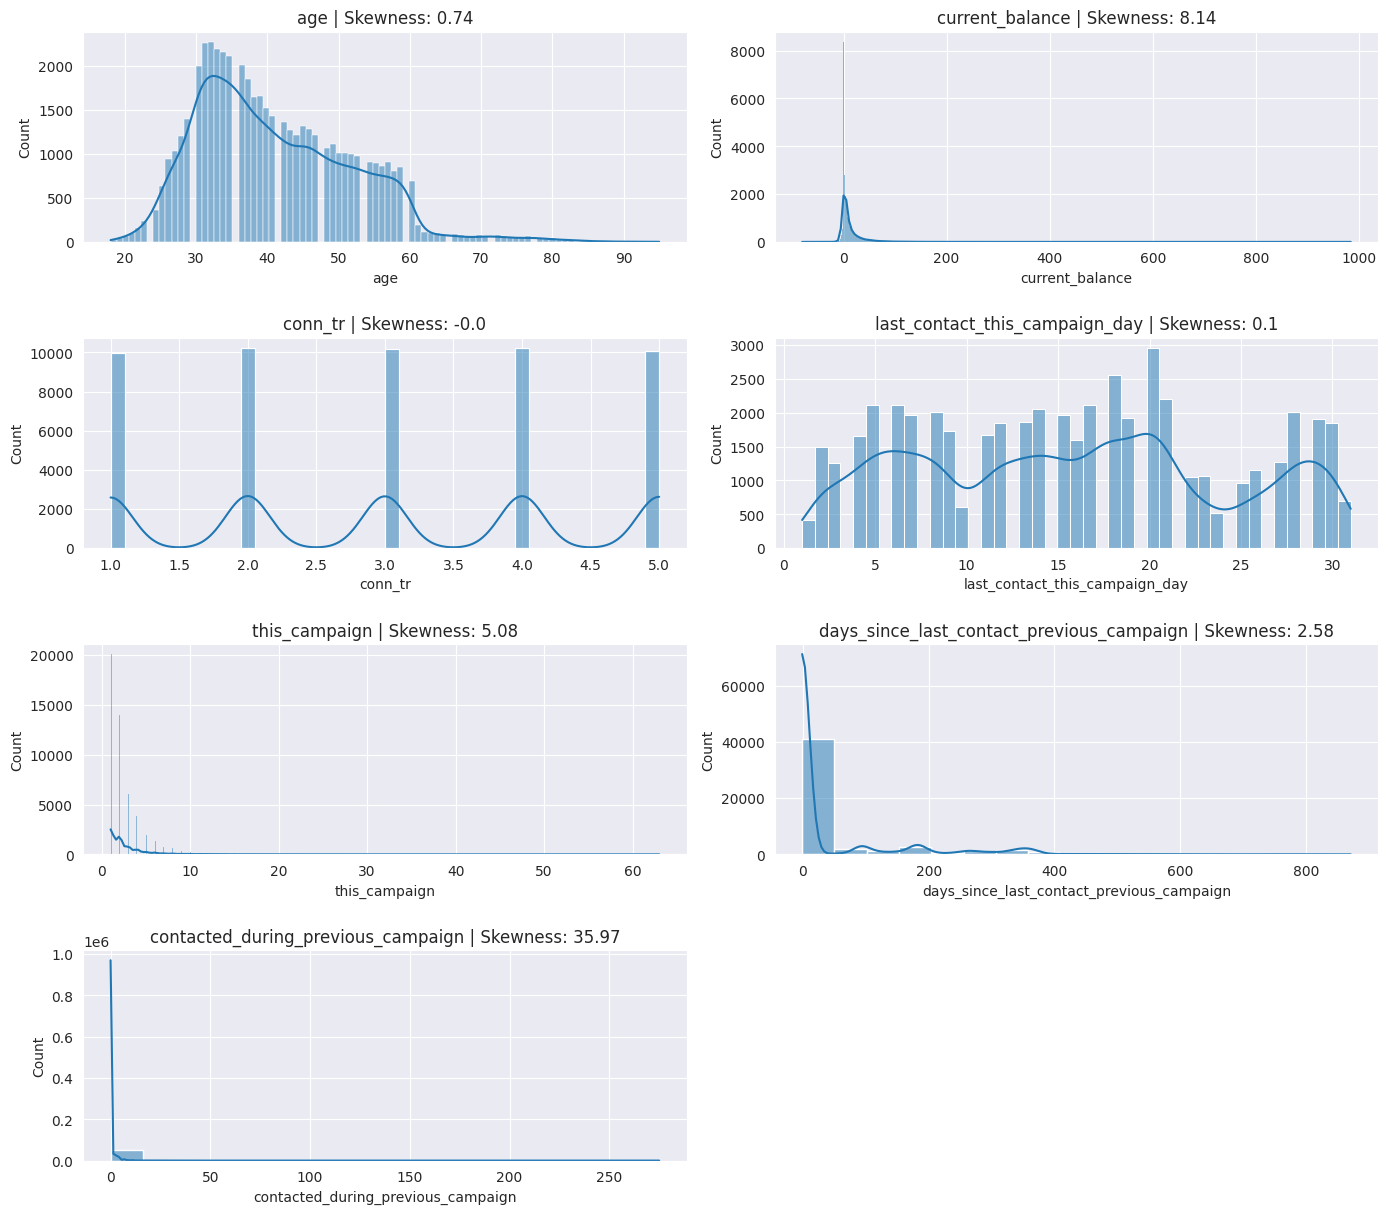

In [56]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include='number').columns[1:-1]

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

Handle Extremely Skewed Features

In [57]:
min_val = df['current_balance'].min()
df['current_balance_log'] = np.log1p(df['current_balance'] - min_val + 1)

df['this_campaign'] = np.log1p(df['this_campaign'])
df['contacted_during_previous_campaign'] = np.log1p(df['contacted_during_previous_campaign'])

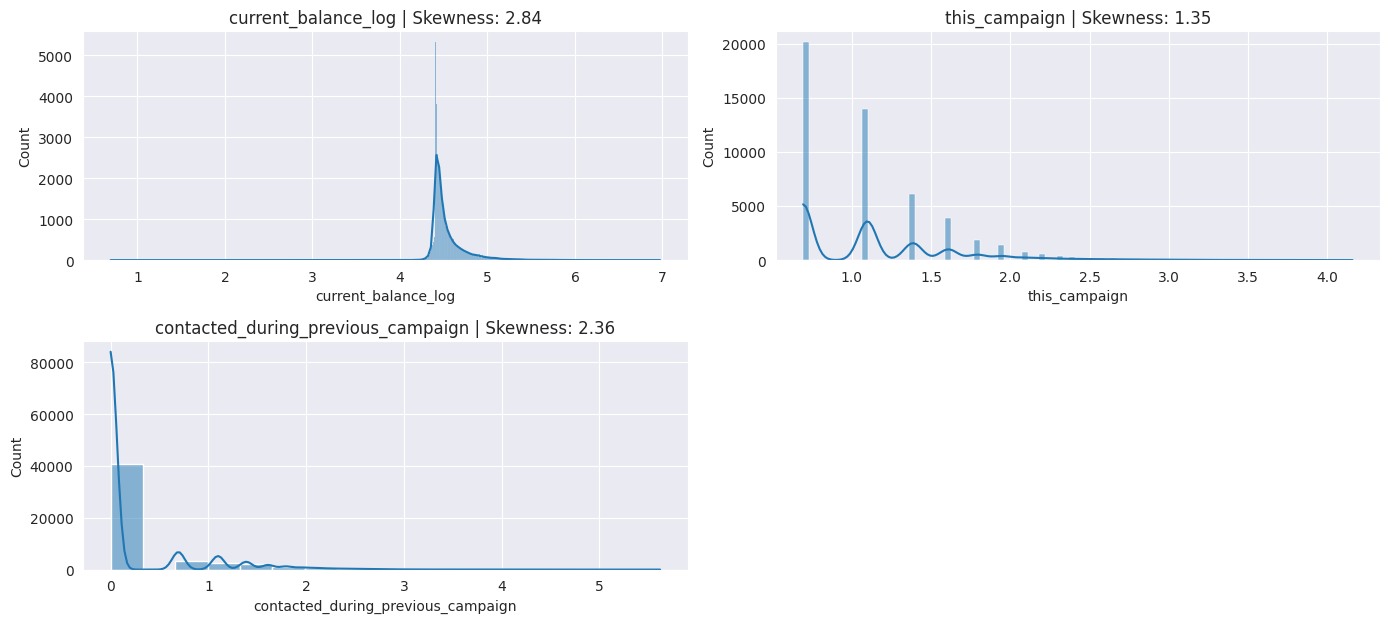

In [58]:
sns.set_style("darkgrid")

numerical_columns = ['current_balance_log', 'this_campaign', 'contacted_during_previous_campaign']

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

Univariate Analysis

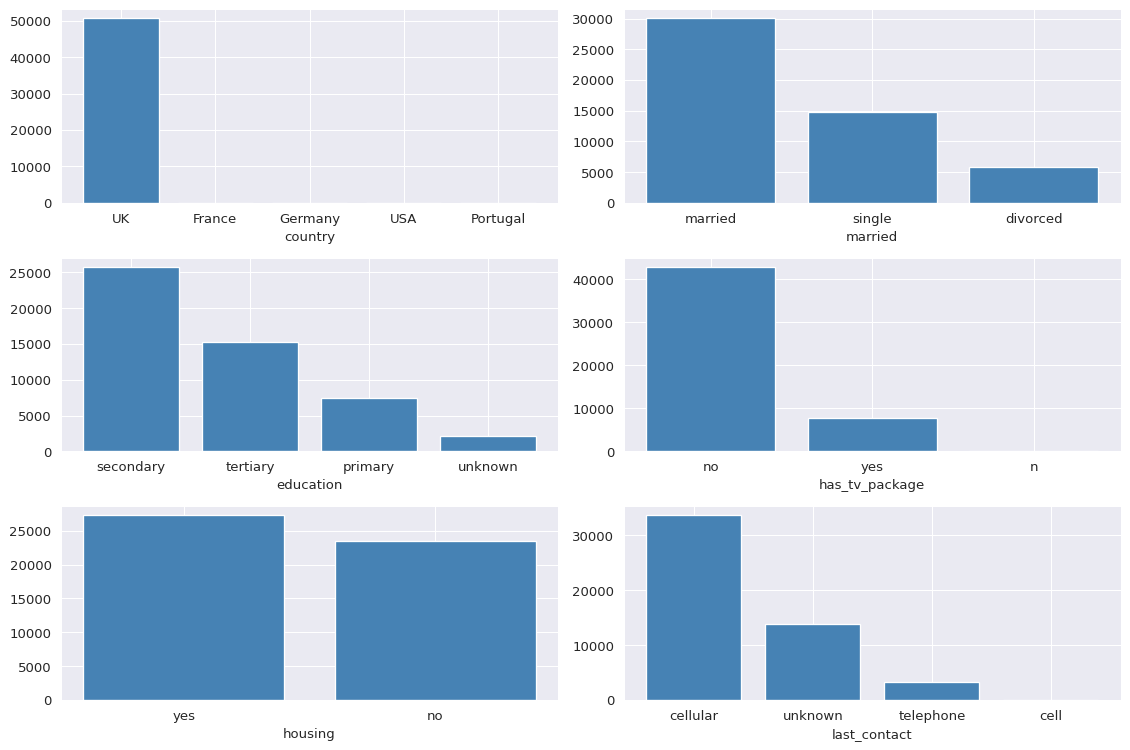

In [59]:
cat_col_filtered = ['country', 'married', 'education', 'has_tv_package', 'housing', 'last_contact']

fig, axs = plt.subplots(3, 2, figsize=(12, 8), dpi=95)
axs = axs.flatten()

for i, col in enumerate(cat_col_filtered):
  counts = df[col].value_counts()
  axs[i].bar(counts.index, counts, color='SteelBlue')
  axs[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [60]:
for col in cat_col_filtered:
  print(df[col].value_counts(), '\n')

country
UK          50657
France          2
Germany         1
USA             1
Portugal        1
Name: count, dtype: int64 

married
married     30045
single      14768
divorced     5849
Name: count, dtype: int64 

education
secondary    25779
tertiary     15314
primary       7474
unknown       2095
Name: count, dtype: int64 

has_tv_package
no     42886
yes     7771
n          5
Name: count, dtype: int64 

housing
yes    27250
no     23412
Name: count, dtype: int64 

last_contact
cellular     33595
unknown      13753
telephone     3312
cell             2
Name: count, dtype: int64 



Handle Heavily Imbalanced Categorical Data

In [61]:
df['country'] = df['country'].apply(lambda x: x if x == 'UK' else 'others')
df['country'].value_counts()

,count
country,
UK,50657
others,5


Handle Data Entry Error

In [62]:
df['has_tv_package'] = df['has_tv_package'].replace({'n': 'no'})
df['has_tv_package'].value_counts()

,count
has_tv_package,
no,42891
yes,7771


Handle Data Glitch

In [63]:
df['last_contact'] = df['last_contact'].replace({'cell': 'cellular'})
df['last_contact'].value_counts()

,count
last_contact,
cellular,33597
unknown,13753
telephone,3312


In [64]:
df = df.drop(columns=["ID", "current_balance"])
df.head()

,town,country,age,job,married,education,arrears,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign,current_balance_log
0,Bristol,UK,39,management,married,tertiary,no,no,yes,unknown,4,11,jun,2.197225,-1,0.000000,unknown,1,4.385645
1,Basildon,UK,53,housemaid,married,primary,no,no,no,cellular,1,28,jul,1.098612,-1,0.000000,unknown,1,4.452136
2,Blackburn,UK,79,retired,divorced,primary,no,no,no,telephone,3,13,jul,0.693147,377,0.693147,success,1,4.701026
3,Oldham,UK,43,services,single,secondary,no,yes,no,cellular,3,13,may,1.098612,-1,0.000000,unknown,0,4.473808
4,Middlesbrough,UK,35,technician,single,secondary,no,no,no,cellular,2,27,aug,2.833213,-1,0.000000,unknown,1,4.450036


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50662 entries, 0 to 50661
Data columns (total 19 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   town                                       50662 non-null  object 
 1   country                                    50662 non-null  object 
 2   age                                        50662 non-null  int64  
 3   job                                        50662 non-null  object 
 4   married                                    50662 non-null  object 
 5   education                                  50662 non-null  object 
 6   arrears                                    50662 non-null  object 
 7   housing                                    50662 non-null  object 
 8   has_tv_package                             50662 non-null  object 
 9   last_contact                               50662 non-null  object 
 10  conn_tr               

**2. Feature Selection**

Train/Test Split

In [66]:
X = df.drop("new_contract_this_campaign", axis='columns')
y = df["new_contract_this_campaign"]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X shape: (50662, 18), y shape: (50662,)


In [67]:
cat_col = [col for col in X.columns if X[col].dtype == 'object']
num_col = [col for col in X.columns if X[col].dtype != 'object']

print("Categorical columns: ", cat_col)
print("Numerical columns: ", num_col)

Categorical columns:  ['town', 'country', 'job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign']
Numerical columns:  ['age', 'conn_tr', 'last_contact_this_campaign_day', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign', 'current_balance_log']


**3.Train Model**

In [68]:
from sklearn.compose import ColumnTransformer

# numeric transformer
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# categorical transformer
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# combine them
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
])

In [69]:
#  Logistic Regression
# Pipeline
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ("clf", LogisticRegression(max_iter=500, random_state=42))
])

# Fit baselines
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign',
                                                   'current_balance_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf', LogisticRegression(max_iter=500, random_state=42))])

In [70]:
# SVM
# Pipeline
pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ("clf", SVC(probability=True, random_state=42))
])

# Fit baselines
pipe_svm.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign',
                                                   'current_balance_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf', SVC(probability=True, random_state=42))])

In [71]:
# Random Forest
preprocessor = ColumnTransformer(transformers=[
    ('num', "passthrough", num_col),
    ('cat', cat_transformer, cat_col)
])

# Pipeline
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Fit baselines
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign',
                                                   'current_balance_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [72]:
y_pred_lr  = pipe_lr.predict(X_test)
y_pred_svm = pipe_svm.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

In [73]:
# Probabilities for curves
y_proba_lr  = pipe_lr.predict_proba(X_test)[:, 1]
y_proba_svm = pipe_svm.predict_proba(X_test)[:, 1]
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]

In [74]:
def report(name, y_true, y_pred, y_proba):
    target_names = ['Yes', 'No']
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    roc = roc_auc_score(y_true, y_proba)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f} | Precision: {pr:.3f} | Recall: {rc:.3f} | F1: {f1:.3f} | ROC AUC: {roc:.3f}")
    print(classification_report(y_true, y_pred, target_names=target_names))
    return acc, pr, rc, f1, roc

In [75]:
metrics_lr  = report("Logistic Regression (baseline)", y_test, y_pred_lr, y_proba_lr)

=== Logistic Regression (baseline) ===
Accuracy: 0.838 | Precision: 0.716 | Recall: 0.284 | F1: 0.407 | ROC AUC: 0.773
              precision    recall  f1-score   support

         Yes       0.85      0.97      0.91      8153
          No       0.72      0.28      0.41      1980

    accuracy                           0.84     10133
   macro avg       0.78      0.63      0.66     10133
weighted avg       0.82      0.84      0.81     10133



In [76]:
metrics_svm = report("SVM (baseline)", y_test, y_pred_svm, y_proba_svm)

=== SVM (baseline) ===
Accuracy: 0.847 | Precision: 0.745 | Recall: 0.330 | F1: 0.457 | ROC AUC: 0.786
              precision    recall  f1-score   support

         Yes       0.86      0.97      0.91      8153
          No       0.74      0.33      0.46      1980

    accuracy                           0.85     10133
   macro avg       0.80      0.65      0.68     10133
weighted avg       0.83      0.85      0.82     10133



In [78]:
metrics_rf  = report("Random Forest (baseline)", y_test, y_pred_rf, y_proba_rf)

=== Random Forest (baseline) ===
Accuracy: 0.879 | Precision: 0.817 | Recall: 0.490 | F1: 0.613 | ROC AUC: 0.907
              precision    recall  f1-score   support

         Yes       0.89      0.97      0.93      8153
          No       0.82      0.49      0.61      1980

    accuracy                           0.88     10133
   macro avg       0.85      0.73      0.77     10133
weighted avg       0.87      0.88      0.87     10133



Confusion Matrices

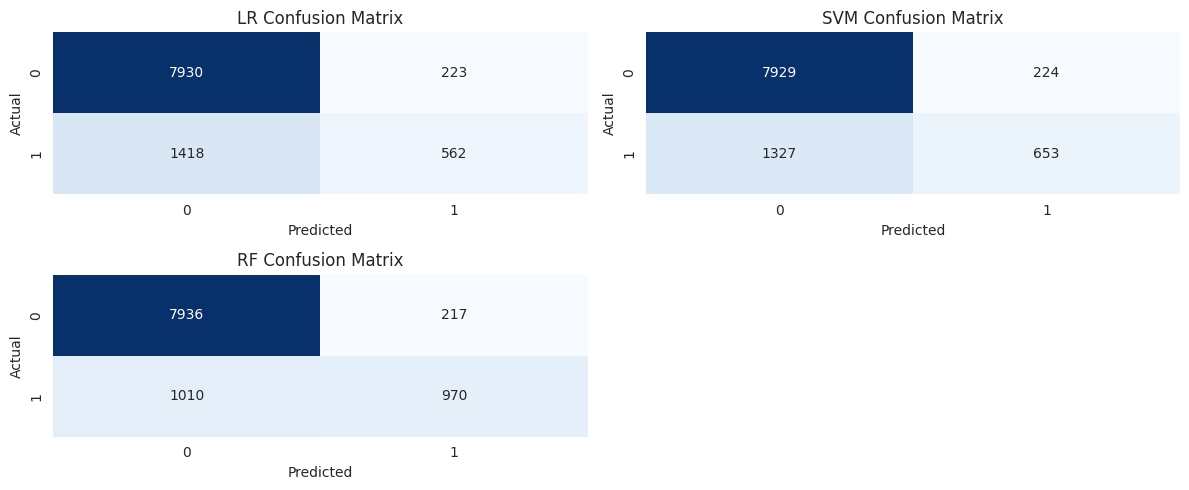

In [79]:
sns.set_style("darkgrid")

plt.figure(figsize=(12, 5))

models = [("LR", y_pred_lr), ("SVM", y_pred_svm), ("RF", y_pred_rf)]

for idx, (name, y_pred) in enumerate(models, start=1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, idx)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

ROC Curves

<Figure size 600x500 with 0 Axes>

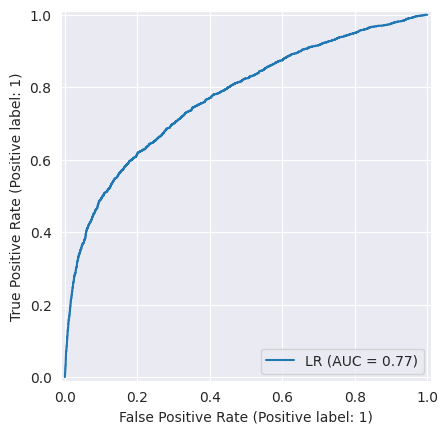

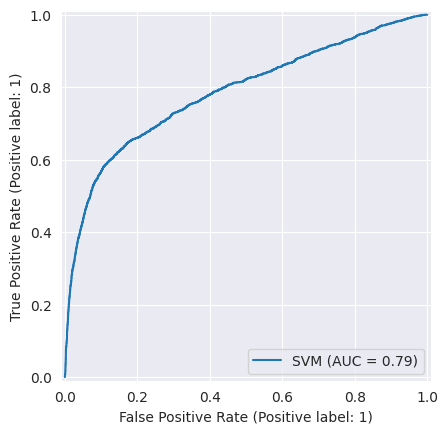

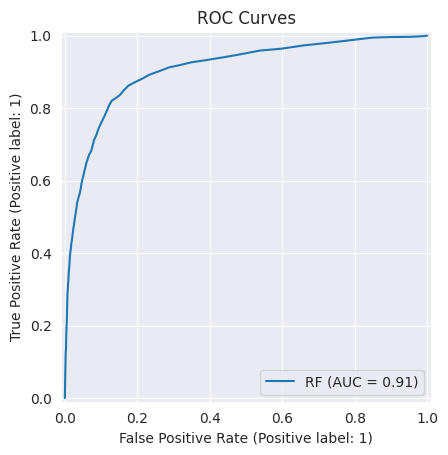

In [80]:
# ROC Curves
fig = plt.figure(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="LR")
RocCurveDisplay.from_predictions(y_test, y_proba_svm, name="SVM")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="RF")
plt.title("ROC Curves")
plt.show()

Precision-Recall curves

<Figure size 600x500 with 0 Axes>

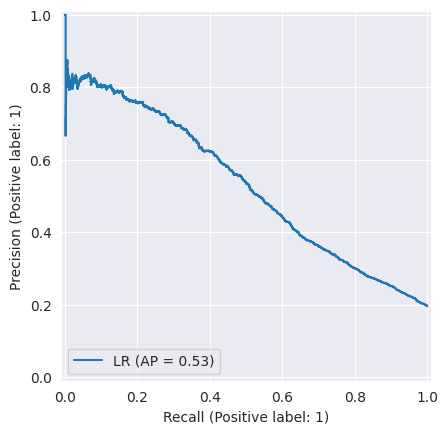

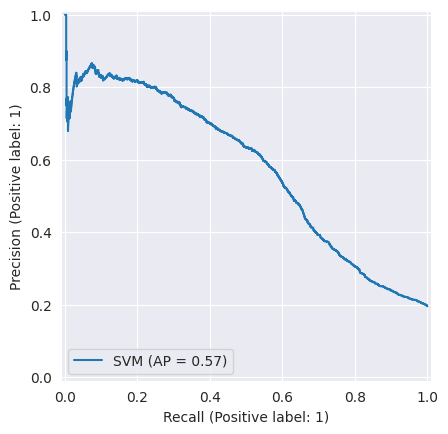

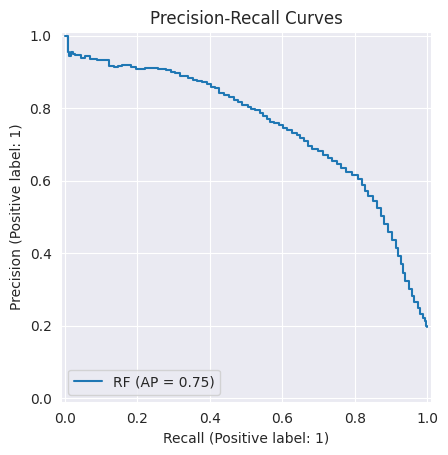

In [81]:
# Precision-Recall curves
fig = plt.figure(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name="LR")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_svm, name="SVM")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name="RF")
plt.title("Precision-Recall Curves")
plt.show()

5-fold Stratified CV scores (Accuracy)

In [34]:
# 5-fold Stratified CV scores (Accuracy)
num_folds = 5
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_lr  = cross_val_score(pipe_lr,  X, y, cv=kf, scoring="accuracy")
cv_svm = cross_val_score(pipe_svm, X, y, cv=kf, scoring="accuracy")

print(f"LR CV Accuracy:  mean={cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print(f"SVM CV Accuracy: mean={cv_svm.mean():.3f} ± {cv_svm.std():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


LR CV Accuracy:  mean=0.836 ± 0.002
SVM CV Accuracy: mean=0.842 ± 0.002


Hyperparameter Tuning

In [35]:
# Logistic Regression
grid_lr = {
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__penalty": ["l2"],
    "clf__C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "clf__max_iter": [5000],
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=grid_lr,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
gs_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'conn_tr',
                                                                          'last_contact_this_campaign_day',
                                                                          'this_campaign',
                                                                          'days_since_last_contact_previous_campaign',
                                                                          'contacted_during_previous_campaign',
                                                                          'cu...
                                                                          'married',
                                                                          'education',
                                                                          'arrears',
                                                                          'housing',
                                                                          'has_tv_package',
                                                                          'last_contact',
                                                                          'last_contact_this_campaign_month',
                                                                          'outcome_previous_campaign'])])),
                                       ('clf',
                                        LogisticRegression(max_iter=500,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0],
                         'clf__max_iter': [5000], 'clf__penalty': ['l2'],
                         'clf__solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [36]:
print("Best LR params:", gs_lr.best_params_, "AUC:", gs_lr.best_score_)

Best LR params: {'clf__C': 0.1, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} AUC: 0.7646521147572669


In [1]:
# SVM
grid_svm = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__kernel": ['linear', 'rbf'],
    "clf__gamma": ['scale', 'auto'],
    "clf__class_weight": [None, 'balanced']
}

rand_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=grid_svm,
    n_iter=30,
    cv=kf,
    verbose=2,
    random_state=42,
    n_jobs=-1
  )
rand_svm.fit(X_train, y_train)

In [ ]:
print("Best LR params:", rand_svm.best_params_, "AUC:", rand_svm.best_score_)